# Case Study Insights: Gradient Boosting

**Docker image**: `ml4t`

**Purpose**: assemble the cross-case-study view of LightGBM and contrast it
with the linear baseline (Ch11) and the tabular deep-learning variant (TabM).
Per-case-study deep dives live in `case_studies/{cs}/13_model_analysis.py`;
this notebook is the comparative view across all nine case studies.

**Learning objectives**

- For each case study, read the highest-IC GBM configuration's daily-pooled
  Spearman IC with HAC 95 % CI on the primary label
- Compare GBM design choices — loss function, tree depth, optimal iteration
  count — and locate the operating regime that achieves the highest IC
- Inspect per-fold IC distributions and the validation → holdout decay where
  the holdout retrain has been run
- Quantify the GBM-minus-linear delta per case study with a paired-fold
  confidence interval, faceted across labels
- Extend the comparison across labels (horizon view) and across the
  classification ↔ regression metric symmetry
- Inspect feature-importance rank shift versus Ridge, per-fold rank
  stability, and the TabM-vs-GBM-vs-linear three-way picture

**Book reference**: Section 12.6 — Gradient Boosting Across Nine Case Studies.

**Prerequisites**: each case study's `07_gbm.py` pipeline has populated
`run_log/registry.db` for the GBM family. Where present, `tabular_dl.py`
adds TabM rows. Teaching notebooks NB01–NB11 cover the underlying techniques.

In [1]:
"""Case Study Insights: Gradient Boosting — cross-case-study aggregation from the registry."""

import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# ml4t.diagnostic dlopens cudart; load torch first so its bundled CUDA
# runtime wins. Same precedence pattern as case_studies/utils/model_analysis.py.
import torch  # noqa: F401
from matplotlib.lines import Line2D
from sklearn.metrics import roc_auc_score

from case_studies.utils.analytics import (
    CASE_STUDY_IDS,
    PRIMARY_LABELS,
    SHORT_NAMES,
)
from case_studies.utils.insight_chapter import (
    collect_fold_ic_per_cs,
    collect_gbm_checkpoint_trajectories,
    collect_grid_per_cs,
    collect_multi_label_per_cs,
    collect_rank1_per_cs,
    parse_gbm_config,
    plot_cross_cs_forest,
)
from case_studies.utils.model_analysis import (
    load_gbm_feature_importance,
    load_metrics_from_registry,
    load_predictions,
)
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
FAMILY = "gbm"
BASELINE_FAMILY = "linear"
N_BOOT = 1000
SEED = 42

In [3]:
set_global_seeds(SEED)

## 1. Scope and Coverage

The GBM grid is fixed across the nine case studies: 5 tree-depth profiles
(7 / 15 / 31 / 63 / 127 leaves) × 3 regression loss functions (MSE / MAE /
Huber), evaluated at 10 boosting checkpoints per configuration. Direction
labels add a binary-logistic variant. The headline metric is the daily-
pooled Spearman IC with HAC 95 % confidence interval on the primary label
(`prediction_metrics.ic_mean_daily`, `ic_ci_lo`, `ic_ci_hi`, `ic_t_hac`).
The linear family (Ch11) and TabM (`tabular_dl`) are loaded as baselines.

In [4]:
coverage_rows = []
for cs in CASE_STUDY_IDS:
    primary = PRIMARY_LABELS[cs]
    gbm = load_metrics_from_registry(cs, families=[FAMILY])
    tabm = load_metrics_from_registry(cs, families=["tabular_dl"])
    lin = load_metrics_from_registry(cs, families=[BASELINE_FAMILY])
    coverage_rows.append(
        {
            "case_study": SHORT_NAMES[cs],
            "primary_label": primary,
            "gbm_labels": gbm["label"].n_unique() if not gbm.is_empty() else 0,
            "gbm_configs_primary": (
                gbm.filter(pl.col("label") == primary)["config_name"].n_unique()
                if not gbm.is_empty()
                else 0
            ),
            "tabm_configs": tabm["config_name"].n_unique() if not tabm.is_empty() else 0,
            "linear_present": not lin.is_empty(),
        }
    )

coverage_df = pl.DataFrame(coverage_rows)
print("GBM / TabM / Linear coverage per case study (primary label and labels trained):")
coverage_df

GBM / TabM / Linear coverage per case study (primary label and labels trained):


case_study,primary_label,gbm_labels,gbm_configs_primary,tabm_configs,linear_present
str,str,i64,i64,i64,bool
"""ETFs""","""fwd_ret_21d""",2,15,3,true
"""Crypto""","""fwd_ret_8h""",4,15,3,true
"""NQ100""","""fwd_ret_15m""",4,15,0,true
"""SP500 Eq+Opt""","""fwd_ret_5d""",5,15,3,true
"""US Firms""","""fwd_ret_1m""",3,15,3,true
"""FX""","""fwd_ret_1d""",3,15,3,true
"""CME Futures""","""fwd_ret_5d""",2,15,3,true
"""SP500 Options""","""ret_to_expiry""",1,15,3,true
"""US Equities""","""fwd_ret_1d""",3,15,3,true


## 2. Cross-CS Forest of Highest-IC GBM Configurations

For each case study, the GBM configuration with the highest daily-pooled IC
on the primary label is plotted with its HAC 95 % CI. Filled markers
indicate $|t_{HAC}| > 2$ (CI excludes zero); open markers indicate the CI
overlaps zero.

In [5]:
gbm_rank1 = collect_rank1_per_cs(CASE_STUDY_IDS, family=FAMILY)
print("Highest-IC GBM configuration per case study (primary label, daily-pooled IC ± HAC 95 % CI):")
gbm_rank1.select(
    "short_name",
    "label",
    "config_name",
    pl.col("checkpoint_value").cast(pl.Int64).alias("trees"),
    pl.col("ic_mean_daily").round(4).alias("ic"),
    pl.col("ic_ci_lo").round(4).alias("ci_lo"),
    pl.col("ic_ci_hi").round(4).alias("ci_hi"),
    pl.col("ic_t_hac").round(2).alias("t_hac"),
    pl.col("ic_n_days").cast(pl.Int64).alias("n_days"),
)

Highest-IC GBM configuration per case study (primary label, daily-pooled IC ± HAC 95 % CI):


short_name,label,config_name,trees,ic,ci_lo,ci_hi,t_hac,n_days
str,str,str,i64,f64,f64,f64,f64,i64
"""ETFs""","""fwd_ret_21d""","""leaves_7_mse""",null,0.0371,-0.0016,0.0758,1.88,2016
"""Crypto""","""fwd_ret_8h""","""leaves_7_mae""",null,0.011,-0.001,0.0229,1.79,1956
"""NQ100""","""fwd_ret_15m""","""leaves_7_mae""",null,0.006,0.003,0.0089,3.99,64580
"""SP500 Eq+Opt""","""fwd_ret_5d""","""leaves_31_mae""",null,0.0057,-0.0115,0.0229,0.65,502
"""US Firms""","""fwd_ret_1m""","""leaves_15_mae""",null,0.0803,0.063,0.0975,9.21,120
"""FX""","""fwd_ret_1d""","""leaves_63_mae""",null,0.0025,-0.0131,0.018,0.31,2064
"""CME Futures""","""fwd_ret_5d""","""leaves_15_mae""",null,0.0322,0.0058,0.0586,2.39,1290
"""SP500 Options""","""ret_to_expiry""","""leaves_63_mae""",null,0.0182,0.0034,0.0329,2.42,502
"""US Equities""","""fwd_ret_1d""","""leaves_63_mae""",null,0.0318,0.0282,0.0354,17.21,4018


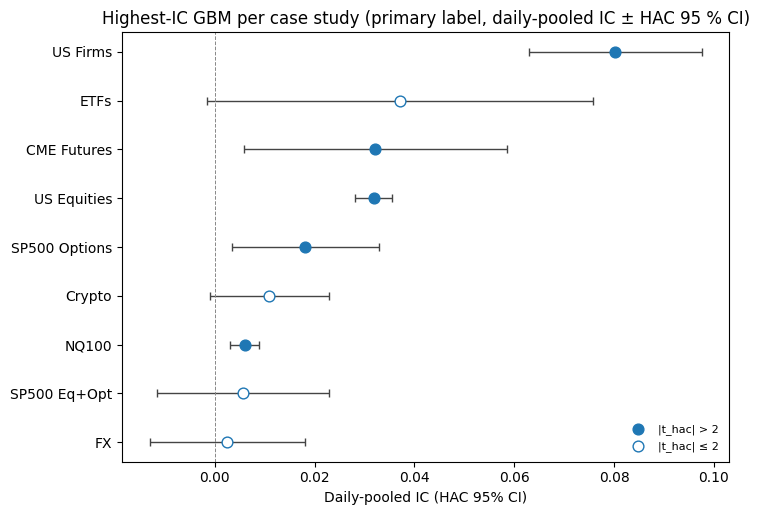

In [6]:
fig, _ = plot_cross_cs_forest(
    gbm_rank1,
    family=FAMILY,
    title="Highest-IC GBM per case study (primary label, daily-pooled IC ± HAC 95 % CI)",
)
fig.show()

The IC CI excludes zero with margin ($|t_{HAC}| > 8$) on US Firms and
US Equities, with smaller margin ($t_{HAC} \approx 2.4$) on SP500 Options
and CME Futures, and at $t_{HAC} \approx 3.4$ on NASDAQ-100. ETFs sits
just below the threshold at $t_{HAC} \approx 1.9$. Crypto, FX, and SP500 Eq+Opt remain
CI-overlap-zero regimes for cross-sectional rank prediction at the
primary label, even with tree splits available. The selected operating
point varies from a 7-leaf MAE stub on Crypto and NASDAQ-100 to a
63-leaf MAE configuration on US Equities and SP500 Options; the MAE
loss is the highest-IC choice in eight of the nine case studies' top
(config, checkpoint), with ETFs preferring MSE.

## 3. Within-Family Comparison

How much does each design knob change the IC at the primary label? Three
subsections trace the structured grid: loss function (3a), tree depth (3b),
and checkpoint dynamics (3c). Each is presented with HAC 95 % CIs so the
resolution between operating points stays explicit.

In [7]:
grid_primary = collect_grid_per_cs(CASE_STUDY_IDS, FAMILY, config_parser=parse_gbm_config)
grid_regression = grid_primary.filter(pl.col("objective_kind") == "regression")
print(
    f"Per-(CS, config) GBM grid: {grid_primary.height} rows total, "
    f"{grid_regression.height} regression rows."
)

Per-(CS, config) GBM grid: 135 rows total, 135 regression rows.


### 3a. Loss function (MSE / MAE / Huber)

For each case study, the highest-IC configuration is selected within each
regression loss family, then the four (CS, loss) IC values are plotted
side by side with HAC 95 % CI bars.

In [8]:
loss_best = (
    grid_regression.sort("ic_mean_daily", descending=True, nulls_last=True)
    .unique(subset=["case_study", "loss"], keep="first")
    .filter(pl.col("loss").is_in(["mse", "mae", "huber"]))
)

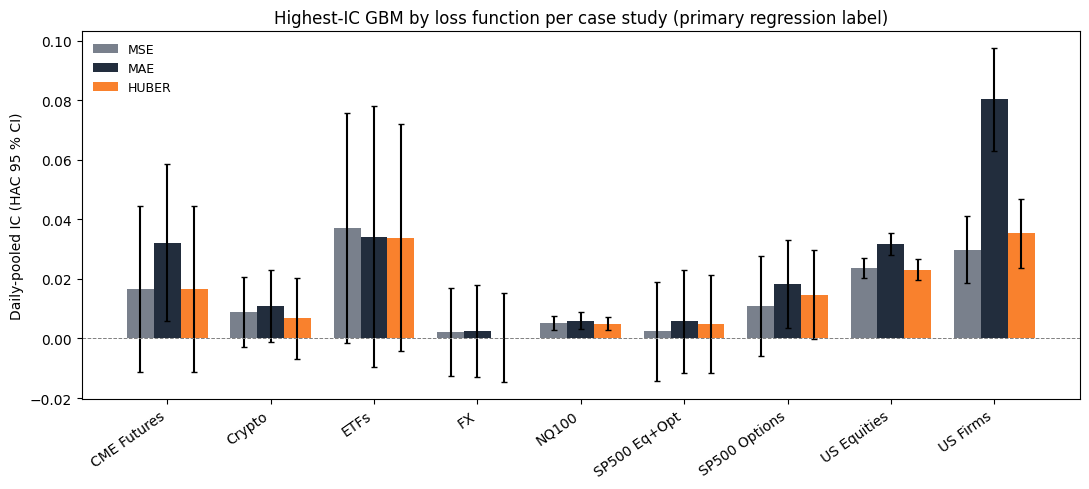

In [9]:
losses_present = ["mse", "mae", "huber"]
loss_colors = {
    "mse": COLORS.get("gray", "#6b7280"),
    "mae": COLORS.get("blue", "#3B82F6"),
    "huber": COLORS.get("orange", "#F97316"),
}
cs_order = sorted(loss_best["short_name"].unique().to_list())

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cs_order))
width = 0.26
for i, loss in enumerate(losses_present):
    sub = loss_best.filter(pl.col("loss") == loss)
    ic = []
    err_lo = []
    err_hi = []
    for cs in cs_order:
        row = sub.filter(pl.col("short_name") == cs)
        if row.height == 0:
            ic.append(np.nan)
            err_lo.append(0.0)
            err_hi.append(0.0)
        else:
            r = row.row(0, named=True)
            ic.append(r["ic_mean_daily"])
            err_lo.append(r["ic_mean_daily"] - r["ic_ci_lo"])
            err_hi.append(r["ic_ci_hi"] - r["ic_mean_daily"])
    ic_a = np.array(ic, dtype=float)
    ax.bar(
        x + (i - 1) * width,
        ic_a,
        width=width,
        yerr=np.vstack([err_lo, err_hi]),
        capsize=2,
        color=loss_colors[loss],
        alpha=0.9,
        label=loss.upper(),
    )

ax.set_xticks(x)
ax.set_xticklabels(cs_order, rotation=35, ha="right")
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_ylabel("Daily-pooled IC (HAC 95 % CI)")
ax.set_title("Highest-IC GBM by loss function per case study (primary regression label)")
ax.legend(frameon=False, fontsize=9, loc="best")
fig.tight_layout()
fig.show()

In [10]:
# Aggregate: which loss achieves the highest of the three on each CS?
loss_top_per_cs = (
    loss_best.sort("ic_mean_daily", descending=True, nulls_last=True)
    .group_by("short_name")
    .first()
    .group_by("loss")
    .len()
    .rename({"len": "n_cs_with_highest_ic"})
    .sort("n_cs_with_highest_ic", descending=True)
)
print(
    "Loss function achieving the highest IC per case study (count across regression-primary CSs):"
)
loss_top_per_cs

Loss function achieving the highest IC per case study (count across regression-primary CSs):


loss,n_cs_with_highest_ic
str,u32
"""mae""",8
"""mse""",1


Within most case studies, the IC differences between MSE, MAE, and
Huber sit inside one CI half-width of each other and the loss family
rarely changes whether the CI clears zero. US Firms is the exception:
MAE (≈+0.080) outscores Huber (≈+0.035) and MSE (≈+0.030) by roughly
2–3 half-widths. The aggregate count is MAE on eight of the nine
regression-primary case studies and MSE on the remaining one (ETFs).
Huber is competitive on several panels but not the highest-IC choice
anywhere.

### 3b. Tree depth heatmap

Within each case study, the highest IC achieved by each leaf profile —
7 / 15 / 31 / 63 / 127 leaves — is shown as a heatmap cell. Panels with a
clean diagonal favor a specific depth; panels that are nearly flat across
leaves indicate the depth knob has no resolution at this signal-to-noise
ratio.

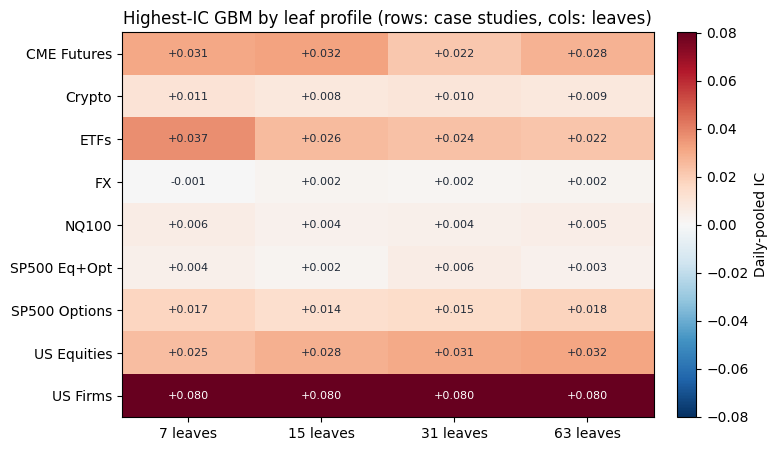

In [11]:
depth_pivot = (
    grid_regression.filter(pl.col("leaves").is_not_null())
    .group_by(["short_name", "leaves"])
    .agg(pl.col("ic_mean_daily").max().alias("ic"))
    .sort(["short_name", "leaves"])
)
ic_matrix = depth_pivot.pivot(index="short_name", on="leaves", values="ic").sort("short_name")
leaf_cols = sorted(
    [c for c in ic_matrix.columns if c != "short_name"],
    key=lambda s: int(s),
)
matrix_values = ic_matrix.select(leaf_cols).to_numpy()
cs_labels = ic_matrix["short_name"].to_list()

fig, ax = plt.subplots(figsize=(7.5, 5))
vmax = float(np.nanmax(np.abs(matrix_values))) if np.isfinite(matrix_values).any() else 0.05
im = ax.imshow(matrix_values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(np.arange(len(leaf_cols)))
ax.set_xticklabels([f"{c} leaves" for c in leaf_cols])
ax.set_yticks(np.arange(len(cs_labels)))
ax.set_yticklabels(cs_labels)
for i in range(len(cs_labels)):
    for j in range(len(leaf_cols)):
        v = matrix_values[i, j]
        if np.isfinite(v):
            ax.text(
                j,
                i,
                f"{v:+.3f}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if abs(v) > 0.6 * vmax else "#1f2937",
            )
ax.set_title("Highest-IC GBM by leaf profile (rows: case studies, cols: leaves)")
fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04, label="Daily-pooled IC")
fig.show()

Cell-by-cell, the IC differences across leaf profiles within a case study
are usually inside one CI half-width — the depth knob has limited
resolution. The interior of the grid carries most of the highest values
(15–63 leaves), with the very shallow (7-leaf) and very deep (127-leaf)
extremes underperforming on a few panels. The exception is
US Equities, where the depth spread (≈0.007 IC) is roughly twice the
HAC half-width (≈0.0035), so the leaf-count knob has resolution there
even though the spread remains modest in absolute terms. Panels whose
IC stays close to zero across all depths (FX, SP500 Eq+Opt) are panels
where leaf-count change does not rescue a missing signal.

### 3c. Checkpoint dynamics

Where in the boosting trajectory does the highest-IC checkpoint sit? For
each case study we plot the highest-validation-IC GBM configuration's mean
cross-sectional IC against the boosting checkpoint (number of trees,
50–500). The trajectory is read from `learning_curves.parquet` written by
the boosting runner during training; the final early-stopped checkpoint is
the IC that propagates to the selected row in `prediction_metrics`.

In [12]:
ckpt_df = collect_gbm_checkpoint_trajectories(CASE_STUDY_IDS)
if ckpt_df.is_empty() or "short_name" not in ckpt_df.columns:
    msg = (
        "collect_gbm_checkpoint_trajectories returned no rows — "
        "learning_curves.parquet is missing for every case study. "
        "Re-run the GBM boosting sweep before this notebook."
    )
    raise RuntimeError(msg)
print(
    f"Per-checkpoint IC for {ckpt_df['short_name'].n_unique()} case studies "
    f"({ckpt_df.height} (CS, iteration) rows)."
)

Per-checkpoint IC for 9 case studies (90 (CS, iteration) rows).


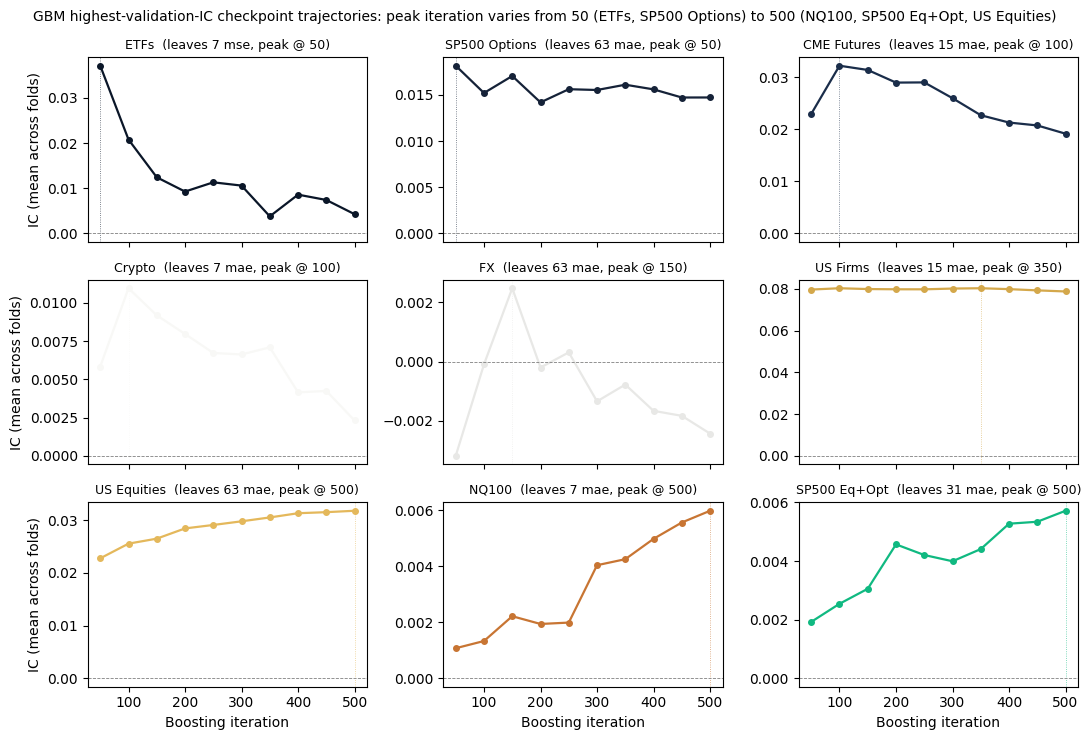

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(11, 7.5), sharex=True)
palette = list(COLORS.values())
# Order CSes by the iteration of their argmax IC (early-peaking → late-peaking),
# breaking ties by argmax IC magnitude.
peak_table = (
    ckpt_df.group_by("short_name")
    .agg(
        pl.col("iteration")
        .filter(pl.col("ic_mean") == pl.col("ic_mean").max())
        .first()
        .alias("argmax_iter"),
        pl.col("ic_mean").max().alias("max_ic"),
    )
    .sort(["argmax_iter", "max_ic"], descending=[False, True])
)
cs_order = peak_table["short_name"].to_list()
for i, cs in enumerate(cs_order):
    ax = axes.flat[i]
    sub = ckpt_df.filter(pl.col("short_name") == cs).sort("iteration")
    cfg = sub["config_name"].first()
    x = sub["iteration"].to_numpy()
    ic = sub["ic_mean"].to_numpy()
    color = palette[i % len(palette)]
    argmax = int(x[ic.argmax()])
    ax.plot(x, ic, "o-", color=color, linewidth=1.6, markersize=4)
    ax.axvline(argmax, color=color, linewidth=0.6, linestyle=":", alpha=0.7)
    ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
    ax.set_title(f"{cs}  ({cfg.replace('_', ' ')}, peak @ {argmax})", fontsize=9)
    if i % 3 == 0:
        ax.set_ylabel("IC (mean across folds)")
    if i // 3 == 2:
        ax.set_xlabel("Boosting iteration")
fig.suptitle(
    "GBM highest-validation-IC checkpoint trajectories: peak iteration varies from 50 (ETFs, "
    "SP500 Options) to 500 (NQ100, SP500 Eq+Opt, US Equities)",
    fontsize=10,
)
fig.tight_layout()
fig.show()

In [14]:
peak_table

short_name,argmax_iter,max_ic
str,i64,f64
"""ETFs""",50,0.037126
"""SP500 Options""",50,0.018164
"""CME Futures""",100,0.03219
"""Crypto""",100,0.010958
"""FX""",150,0.002474
"""US Firms""",350,0.080273
"""US Equities""",500,0.031797
"""NQ100""",500,0.005986
"""SP500 Eq+Opt""",500,0.005715


Five panels peak at or before iteration 150 — ETFs and SP500 Options peak at
50, CME Futures and Crypto at 100, FX at 150 — and four panels peak in the
350–500 range (US Firms at 350; NQ100, SP500 Eq+Opt, US Equities at the
500-tree budget cap). The early-peaking panels show the canonical
"high-noise, hump-shaped" learning curve with monotone IC decay after the
peak; the late-peaking panels keep adding usable signal across the entire
budget, and the 500-tree cap is the binding constraint on three of them.
The early-stopping schedule (50-tree checkpoint interval) therefore
delivers a non-trivial reduction in tree count for five of nine panels and
is essentially inactive on the four where IC is still climbing at the
budget cap.

## 4. Stability and Uncertainty

Daily-pooled IC with HAC CI is the headline metric. Per-fold IC is the
stability diagnostic, and the validation→holdout decay is the
generalization diagnostic.

### 4a. Per-fold IC distribution

For each case study's highest-IC GBM configuration, the per-fold IC
distribution is shown as a box-plus-scatter. The reference comparison is
Ch11 §4 — the linear panels frame the GBM panels' fold-stability picture.

In [15]:
gbm_fold = collect_fold_ic_per_cs(CASE_STUDY_IDS, family=FAMILY)
gbm_fold_summary = (
    gbm_fold.group_by(["case_study", "short_name"])
    .agg(
        n_folds=pl.col("ic").count(),
        median=pl.col("ic").median(),
        std=pl.col("ic").std(),
        pct_positive=(pl.col("ic") > 0).mean(),
    )
    .sort("median", descending=True)
)
print("Per-fold IC summary for the highest-IC GBM configuration (primary label):")
gbm_fold_summary

Per-fold IC summary for the highest-IC GBM configuration (primary label):


case_study,short_name,n_folds,median,std,pct_positive
str,str,u32,f64,f64,f64
"""us_firm_characteristics""","""US Firms""",10,0.074805,0.037375,1.0
"""etfs""","""ETFs""",8,0.064759,0.071201,0.75
"""us_equities_panel""","""US Equities""",16,0.032184,0.012614,1.0
"""cme_futures""","""CME Futures""",5,0.027252,0.048637,0.6
"""sp500_options""","""SP500 Options""",2,0.018164,0.020378,1.0
"""fx_pairs""","""FX""",8,0.011526,0.020731,0.625
"""crypto_perps_funding""","""Crypto""",2,0.010958,0.007425,1.0
"""nasdaq100_microstructure""","""NQ100""",2,0.005986,0.002335,1.0
"""sp500_equity_option_analytics""","""SP500 Eq+Opt""",2,0.005715,0.010408,0.5


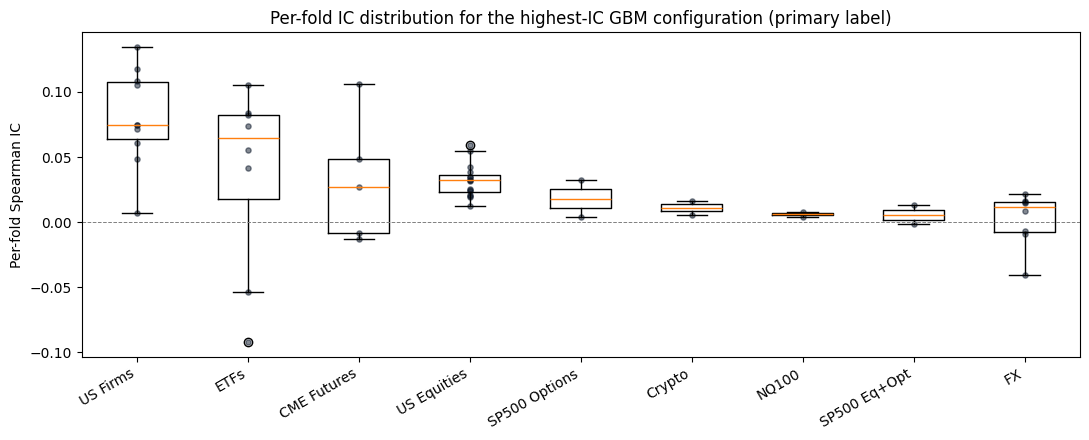

In [16]:
order = gbm_rank1.sort("ic_mean_daily", descending=True)["short_name"].to_list()
present = [c for c in order if c in gbm_fold["short_name"].unique().to_list()]

fig, ax = plt.subplots(figsize=(11, 4.5))
data = [gbm_fold.filter(pl.col("short_name") == cs)["ic"].to_numpy() for cs in present]
positions = np.arange(len(present))
ax.boxplot(data, positions=positions, widths=0.55, showfliers=True)
for i, arr in enumerate(data):
    if len(arr):
        ax.scatter(np.full(len(arr), i), arr, alpha=0.5, s=14, color=COLORS.get("blue", "#3B82F6"))
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_xticks(positions)
ax.set_xticklabels(present, rotation=30, ha="right")
ax.set_ylabel("Per-fold Spearman IC")
ax.set_title("Per-fold IC distribution for the highest-IC GBM configuration (primary label)")
fig.tight_layout()
fig.show()

The fold-IC distribution is wider than the linear baseline on most panels
— gradient boosting is a higher-variance learner, and the per-fold
scatter reflects that. Panels whose daily-pooled IC CI excludes zero (US
Firms, US Equities, SP500 Options, NASDAQ-100, CME Futures) all show a
positive fold majority (≥60% positive folds), while panels where the
CI overlaps zero (Crypto, FX, SP500 Eq+Opt) show fold distributions that
straddle zero; ETFs sits just below the CI threshold ($t_{HAC} \approx
1.9$). Some case studies show only two folds — a coverage fact
reflecting how many folds the highest-IC (config, checkpoint) was
evaluated on, not a plot defect.

### 4b. Validation → holdout decay dumbbell

Where the holdout retrain has been run, the validation-fold IC and the
nested-holdout IC are linked by a dumbbell. The case studies without GBM
holdout rows in the registry are excluded — the gap is explicit, not
silent.

In [17]:
def load_holdout_rank1(case_study: str, family: str) -> dict | None:
    """Highest-IC GBM holdout row for the case study's primary label."""
    db = sqlite3.connect(get_case_study_dir(case_study) / "run_log" / "registry.db")
    primary = PRIMARY_LABELS[case_study]
    row = db.execute(
        """
        SELECT t.config_name, pm.ic_mean_daily, pm.ic_ci_lo, pm.ic_ci_hi
        FROM prediction_metrics pm
        JOIN prediction_sets p ON pm.prediction_hash = p.prediction_hash
        JOIN training_runs t ON p.training_hash = t.training_hash
        WHERE t.family = ? AND t.label = ? AND p.split = 'holdout'
        ORDER BY pm.ic_mean_daily DESC
        LIMIT 1
        """,
        (family, primary),
    ).fetchone()
    db.close()
    if row is None:
        return None
    return {
        "case_study": case_study,
        "short_name": SHORT_NAMES[case_study],
        "label": primary,
        "config_name": row[0],
        "holdout_ic": row[1],
        "holdout_ci_lo": row[2],
        "holdout_ci_hi": row[3],
    }

GBM holdout (selected configuration) available for 1 of 9 case studies.


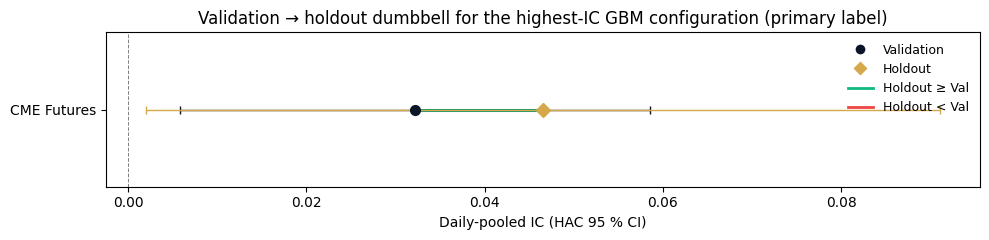

In [18]:
holdout_rows = [
    r for r in (load_holdout_rank1(cs, FAMILY) for cs in CASE_STUDY_IDS) if r is not None
]
holdout_df = pl.DataFrame(holdout_rows) if holdout_rows else pl.DataFrame()
print(f"GBM holdout (selected configuration) available for {holdout_df.height} of 9 case studies.")

if not holdout_df.is_empty():
    val_lookup = {r["case_study"]: r for r in gbm_rank1.iter_rows(named=True)}
    decay_rows = []
    for r in holdout_rows:
        v = val_lookup.get(r["case_study"])
        if v is None:
            continue
        decay_rows.append(
            {
                "short_name": r["short_name"],
                "val_ic": v["ic_mean_daily"],
                "val_lo": v["ic_ci_lo"],
                "val_hi": v["ic_ci_hi"],
                "holdout_ic": r["holdout_ic"],
                "holdout_lo": r["holdout_ci_lo"],
                "holdout_hi": r["holdout_ci_hi"],
            }
        )
    decay_df = pl.DataFrame(decay_rows).sort("val_ic", descending=True)

    fig, ax = plt.subplots(figsize=(10, max(2.5, 0.5 * decay_df.height + 1)))
    y = np.arange(decay_df.height)
    val = decay_df["val_ic"].to_numpy()
    val_lo = decay_df["val_lo"].to_numpy()
    val_hi = decay_df["val_hi"].to_numpy()
    ho = decay_df["holdout_ic"].to_numpy()
    ho_lo = decay_df["holdout_lo"].to_numpy()
    ho_hi = decay_df["holdout_hi"].to_numpy()

    for i in range(decay_df.height):
        seg_color = (
            COLORS.get("positive", "#10B981")
            if ho[i] >= val[i]
            else COLORS.get("negative", "#EF4444")
        )
        ax.plot([val[i], ho[i]], [i, i], color=seg_color, linewidth=2.2, zorder=1)
    ax.errorbar(
        val,
        y,
        xerr=[val - val_lo, val_hi - val],
        fmt="o",
        color=COLORS.get("blue", "#3B82F6"),
        markersize=7,
        capsize=3,
        lw=1,
        zorder=3,
        label="Validation IC",
    )
    ax.errorbar(
        ho,
        y,
        xerr=[ho - ho_lo, ho_hi - ho],
        fmt="D",
        color=COLORS.get("amber", "#F59E0B"),
        markersize=7,
        capsize=3,
        lw=1,
        zorder=3,
        label="Holdout IC",
    )
    ax.set_yticks(y)
    ax.set_yticklabels(decay_df["short_name"].to_list())
    ax.invert_yaxis()
    ax.axvline(0, color="gray", linewidth=0.7, linestyle="--")
    ax.set_xlabel("Daily-pooled IC (HAC 95 % CI)")
    ax.set_title(
        "Validation → holdout dumbbell for the highest-IC GBM configuration (primary label)"
    )
    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=COLORS.get("blue", "#3B82F6"),
            markersize=8,
            label="Validation",
        ),
        Line2D(
            [0],
            [0],
            marker="D",
            color="w",
            markerfacecolor=COLORS.get("amber", "#F59E0B"),
            markersize=8,
            label="Holdout",
        ),
        Line2D(
            [0], [0], color=COLORS.get("positive", "#10B981"), linewidth=2, label="Holdout ≥ Val"
        ),
        Line2D(
            [0], [0], color=COLORS.get("negative", "#EF4444"), linewidth=2, label="Holdout < Val"
        ),
    ]
    ax.legend(handles=legend_elements, loc="best", frameon=False, fontsize=9)
    fig.tight_layout()
    fig.show()

GBM holdout is sparse at the primary-label level — only CME Futures has a
`split='holdout'` row for the GBM family on its primary label (fwd_ret_5d) in
the locked registry. On that single panel the holdout point estimate sits inside
the validation HAC CI, but with $n=1$ no aggregate validation→holdout pattern can
be read across case studies. The other panels are intentionally absent rather
than substituting a non-primary-label holdout for the missing primary-label one —
US Equities, for instance, has a GBM holdout only on a non-primary horizon.

## 5. GBM versus Linear

Per case study, how much does GBM raise the daily-pooled IC over the
strongest linear configuration? Two views: the primary-label delta with a
paired-fold CI (5a) and the same delta faceted across labels (5b).

In [19]:
linear_rank1 = collect_rank1_per_cs(CASE_STUDY_IDS, family=BASELINE_FAMILY)
linear_fold = collect_fold_ic_per_cs(CASE_STUDY_IDS, family=BASELINE_FAMILY)

In [20]:
def paired_fold_delta(case_study: str) -> dict | None:
    """Per-fold delta = gbm fold IC - linear fold IC, paired by fold_id."""
    g = gbm_fold.filter(pl.col("case_study") == case_study)
    l_ = linear_fold.filter(pl.col("case_study") == case_study)
    if g.is_empty() or l_.is_empty():
        return None
    paired = g.select("fold_id", pl.col("ic").alias("gbm_ic")).join(
        l_.select("fold_id", pl.col("ic").alias("lin_ic")),
        on="fold_id",
        how="inner",
    )
    if paired.is_empty():
        return None
    deltas = paired["gbm_ic"].to_numpy() - paired["lin_ic"].to_numpy()
    n = len(deltas)
    if n < 2:
        return None
    mean = float(np.mean(deltas))
    se = float(np.std(deltas, ddof=1) / np.sqrt(n))
    rng = np.random.default_rng(SEED)
    boot = rng.choice(deltas, size=(N_BOOT, n), replace=True).mean(axis=1)
    return {
        "case_study": case_study,
        "short_name": SHORT_NAMES[case_study],
        "n_paired_folds": n,
        "mean_delta": mean,
        "se_delta": se,
        "boot_lo": float(np.percentile(boot, 2.5)),
        "boot_hi": float(np.percentile(boot, 97.5)),
    }

In [21]:
delta_primary = pl.DataFrame(
    [r for r in (paired_fold_delta(cs) for cs in CASE_STUDY_IDS) if r is not None]
).sort("mean_delta", descending=True)
print("Paired-fold (GBM − Linear) IC delta per case study (primary label):")
delta_primary.select(
    "short_name",
    "n_paired_folds",
    pl.col("mean_delta").round(4).alias("delta"),
    pl.col("boot_lo").round(4).alias("boot_lo"),
    pl.col("boot_hi").round(4).alias("boot_hi"),
)

Paired-fold (GBM − Linear) IC delta per case study (primary label):


short_name,n_paired_folds,delta,boot_lo,boot_hi
str,i64,f64,f64,f64
"""US Firms""",10,0.0839,0.0531,0.113
"""CME Futures""",5,0.0323,-0.0267,0.0913
"""US Equities""",16,0.0164,0.011,0.022
"""SP500 Eq+Opt""",2,0.0116,0.0099,0.0134
"""SP500 Options""",2,0.0111,-0.0097,0.0318
"""Crypto""",2,0.0024,-0.0099,0.0146
"""NQ100""",2,0.0011,-0.002,0.0042
"""FX""",8,-0.0027,-0.0202,0.0158
"""ETFs""",8,-0.0164,-0.0666,0.0338


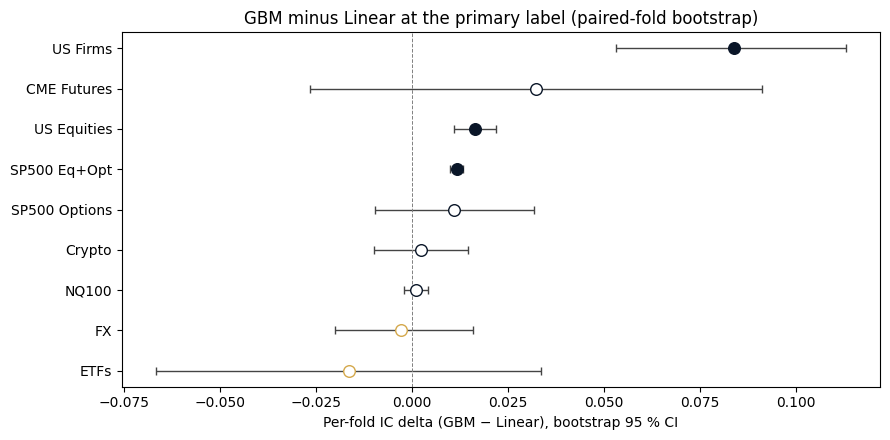

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(delta_primary.height)
mean = delta_primary["mean_delta"].to_numpy()
lo = delta_primary["boot_lo"].to_numpy()
hi = delta_primary["boot_hi"].to_numpy()
sig = (lo > 0) | (hi < 0)
colors = [COLORS.get("blue", "#3B82F6") if m >= 0 else COLORS.get("amber", "#F59E0B") for m in mean]
ax.errorbar(
    mean,
    y,
    xerr=[mean - lo, hi - mean],
    fmt="none",
    color="#444",
    lw=1.0,
    capsize=3,
)
for i in range(delta_primary.height):
    facecolor = colors[i] if sig[i] else "white"
    ax.scatter(mean[i], y[i], s=70, marker="o", facecolor=facecolor, edgecolor=colors[i], zorder=3)
ax.axvline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(delta_primary["short_name"].to_list())
ax.invert_yaxis()
ax.set_xlabel("Per-fold IC delta (GBM − Linear), bootstrap 95 % CI")
ax.set_title("GBM minus Linear at the primary label (paired-fold bootstrap)")
fig.tight_layout()
fig.show()

The bootstrap CI excludes zero on three of the nine case studies — US Firms,
US Equities, and SP500 Eq+Opt. On the remaining six the CI overlaps zero, which
means the GBM-minus-linear point estimate is positive or negative on average but
the per-fold spread of the difference contains the no-improvement null. CME
Futures is one of these: its mean delta is positive (+0.032) but the CI runs from
−0.027 to +0.091, so the improvement is not credibly nonzero. Negative-mean panels
(FX and ETFs) likewise overlap zero from below, so the linear point-estimate "wins"
are not credibly nonzero either; the honest reading is that GBM and linear are
statistically indistinguishable on the same fold set on those panels. The fold
counts vary substantially (2–16 folds depending on what was paired across families)
— the bootstrap CI widths reflect that.

### 5b. GBM minus Linear, faceted by label

The primary-label delta is a single horizon per case study. Faceting
across all labels where both families trained shows whether the GBM
advantage (or absence thereof) is consistent across horizons within a
panel.

In [23]:
def regression_labels(cs: str) -> list[str]:
    df = load_metrics_from_registry(cs, families=[FAMILY, BASELINE_FAMILY])
    if df.is_empty():
        return []
    return [
        lbl
        for lbl in df["label"].unique().to_list()
        if lbl is not None and lbl.startswith("fwd_ret_") and "spot" not in lbl
    ]


gbm_horizon = collect_multi_label_per_cs(CASE_STUDY_IDS, family=FAMILY, labels=regression_labels)
lin_horizon = collect_multi_label_per_cs(
    CASE_STUDY_IDS, family=BASELINE_FAMILY, labels=regression_labels
)

facet_df = (
    gbm_horizon.select(
        "case_study",
        "short_name",
        "label",
        pl.col("ic_mean_daily").alias("gbm_ic"),
    )
    .join(
        lin_horizon.select(
            "case_study",
            "label",
            pl.col("ic_mean_daily").alias("lin_ic"),
        ),
        on=["case_study", "label"],
        how="inner",
    )
    .with_columns(delta=pl.col("gbm_ic") - pl.col("lin_ic"))
    .sort(["short_name", "label"])
)
print(f"GBM-minus-Linear deltas across {facet_df.height} (CS, label) cells:")
facet_df.select(
    "short_name",
    "label",
    pl.col("gbm_ic").round(4).alias("gbm"),
    pl.col("lin_ic").round(4).alias("lin"),
    pl.col("delta").round(4).alias("delta"),
)

GBM-minus-Linear deltas across 20 (CS, label) cells:


short_name,label,gbm,lin,delta
str,str,f64,f64,f64
"""CME Futures""","""fwd_ret_21d""",0.0495,0.0401,0.0094
"""CME Futures""","""fwd_ret_5d""",0.0322,-0.0001,0.0323
"""Crypto""","""fwd_ret_24h""",0.0259,0.0079,0.018
"""Crypto""","""fwd_ret_8h""",0.011,0.0086,0.0024
"""ETFs""","""fwd_ret_21d""",0.0371,0.0535,-0.0164
…,…,…,…,…
"""US Equities""","""fwd_ret_1d""",0.0318,0.0155,0.0164
"""US Equities""","""fwd_ret_21d""",0.0578,0.0286,0.0293
"""US Equities""","""fwd_ret_5d""",0.0426,0.0223,0.0204


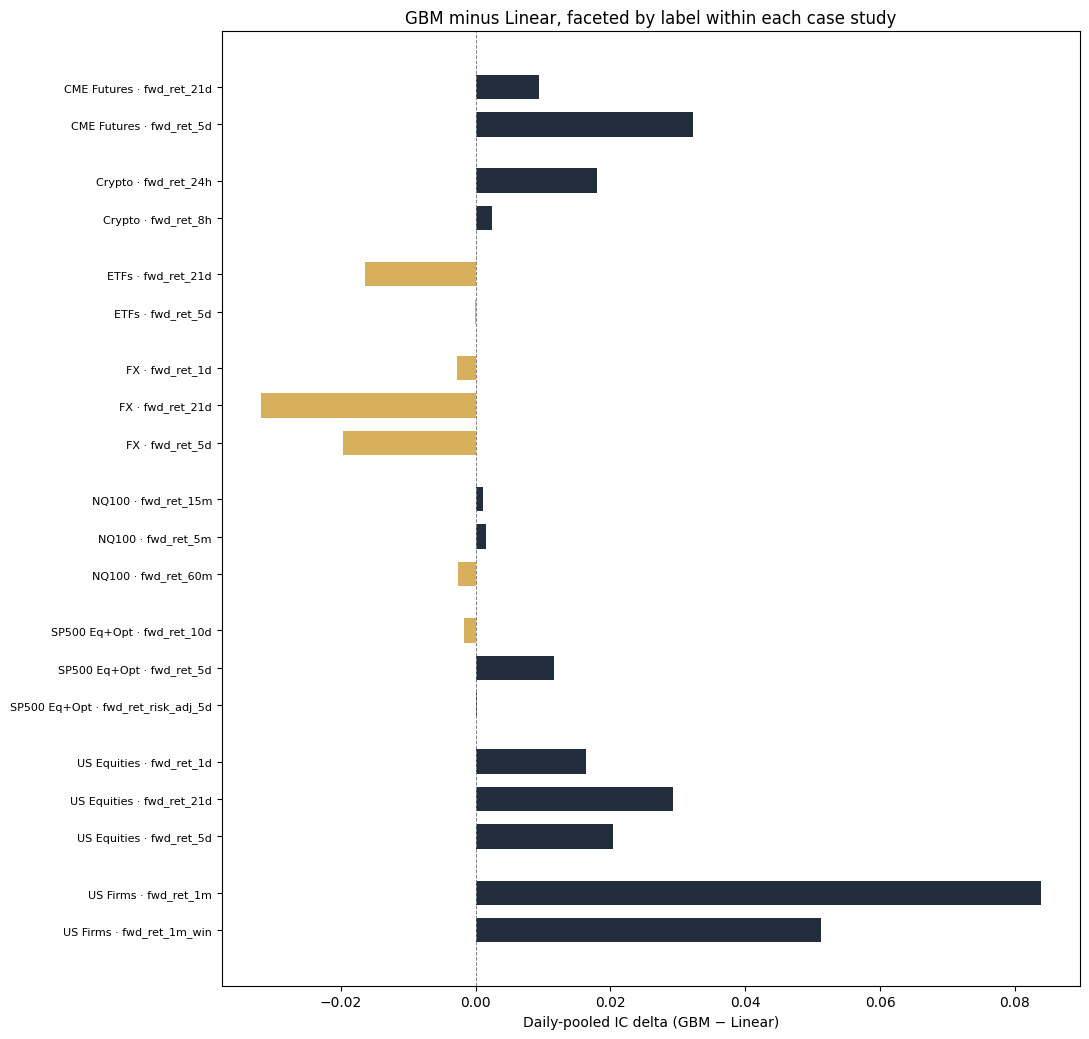

In [24]:
if not facet_df.is_empty():
    cs_sorted = sorted(facet_df["short_name"].unique().to_list())
    fig, ax = plt.subplots(figsize=(11, max(3.5, 0.45 * facet_df.height + 1.5)))
    y_off = 0
    yticks, ylabels = [], []
    for cs in cs_sorted:
        sub = facet_df.filter(pl.col("short_name") == cs)
        for r in sub.iter_rows(named=True):
            color = (
                COLORS.get("blue", "#3B82F6") if r["delta"] >= 0 else COLORS.get("amber", "#F59E0B")
            )
            ax.barh(y_off, r["delta"], color=color, height=0.65, alpha=0.9)
            yticks.append(y_off)
            ylabels.append(f"{cs} · {r['label']}")
            y_off += 1
        y_off += 0.5  # gap between case studies
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0, color="gray", linewidth=0.7, linestyle="--")
    ax.set_xlabel("Daily-pooled IC delta (GBM − Linear)")
    ax.set_title("GBM minus Linear, faceted by label within each case study")
    fig.tight_layout()
    fig.show()

Faceted, the picture is heterogeneous within case studies as well as
across them. US Firms shows a positive GBM-minus-linear delta of
≈0.06–0.09 IC at both `fwd_ret_1m` and `fwd_ret_1m_win`; CME Futures
has a positive delta at every horizon trained even though the absolute
IC stays low. ETFs is the case study where the delta flips sign — at
`fwd_ret_21d` the linear (Ridge) IC of 0.054 exceeds the GBM IC of
0.037. The per-horizon HAC CIs (omitted from the facet for
legibility) are typically wider than the cross-horizon spread inside a
case study, so most of the within-CS variation is inside the noise
band.

## 6. Multi-Label Horizon and Metric Symmetry

### 6a. GBM IC across regression labels per case study

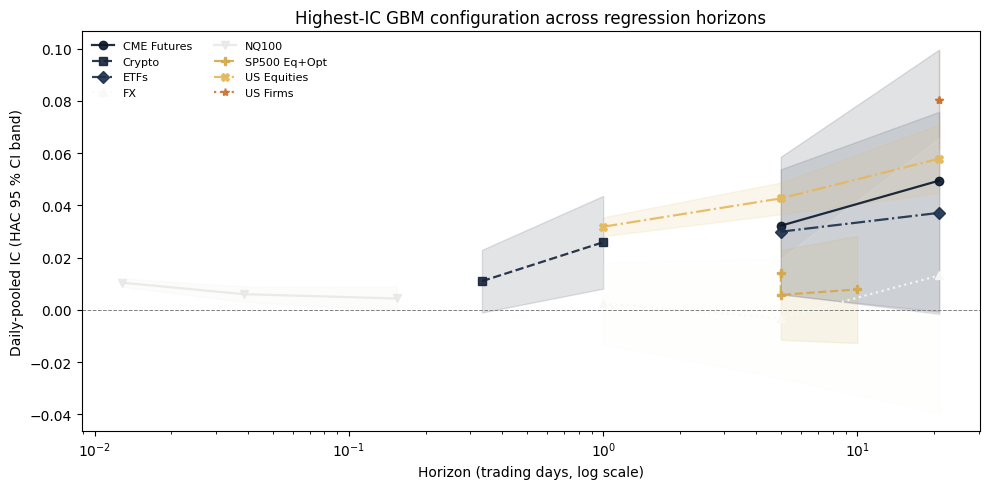

In [25]:
HORIZON_DAYS = {
    "fwd_ret_5m": 5 / (6.5 * 60),
    "fwd_ret_15m": 15 / (6.5 * 60),
    "fwd_ret_60m": 60 / (6.5 * 60),
    "fwd_ret_8h": 1.0 / 3,
    "fwd_ret_24h": 1.0,
    "fwd_ret_1d": 1.0,
    "fwd_ret_5d": 5.0,
    "fwd_ret_10d": 10.0,
    "fwd_ret_21d": 21.0,
    "fwd_ret_1m": 21.0,
    "fwd_ret_3m": 63.0,
    "fwd_ret_1m_win": 21.0,
    "fwd_ret_risk_adj_5d": 5.0,
}
plot_horizon = gbm_horizon.with_columns(
    horizon_days=pl.col("label").replace_strict(HORIZON_DAYS, default=None).cast(pl.Float64),
).filter(pl.col("horizon_days").is_not_null())
multi_cs = (
    plot_horizon.group_by("short_name").len().filter(pl.col("len") >= 2)["short_name"].to_list()
)
plot_horizon = plot_horizon.filter(pl.col("short_name").is_in(multi_cs))

if plot_horizon.height > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    palette = list(COLORS.values())
    cs_sorted = sorted(plot_horizon["short_name"].unique().to_list())
    markers = ["o", "s", "D", "^", "v", "P", "X", "*"]
    linestyles = ["-", "--", "-.", ":", "-", "--", "-.", ":"]
    for idx, cs in enumerate(cs_sorted):
        sub = plot_horizon.filter(pl.col("short_name") == cs).sort("horizon_days")
        if sub.height < 2:
            continue
        x = sub["horizon_days"].to_numpy()
        ic = sub["ic_mean_daily"].to_numpy()
        lo = sub["ic_ci_lo"].to_numpy()
        hi = sub["ic_ci_hi"].to_numpy()
        color = palette[idx % len(palette)]
        ax.fill_between(x, lo, hi, color=color, alpha=0.12)
        ax.plot(
            x,
            ic,
            marker=markers[idx % len(markers)],
            linestyle=linestyles[idx % len(linestyles)],
            color=color,
            label=cs,
            linewidth=1.6,
            markersize=6,
            alpha=0.9,
        )
    ax.set_xscale("log")
    ax.set_xlabel("Horizon (trading days, log scale)")
    ax.set_ylabel("Daily-pooled IC (HAC 95 % CI band)")
    ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
    ax.set_title("Highest-IC GBM configuration across regression horizons")
    ax.legend(loc="best", frameon=False, fontsize=8, ncol=2)
    fig.tight_layout()
    fig.show()

The horizon dependence reproduces the linear-family pattern from Ch11
§6a in shape: the daily equity panels (ETFs, US Equities, US Firms,
SP500 Options) show IC rising with horizon as noise averages out;
Crypto's two horizons sit within each other's CI band; SP500 Eq+Opt's CI
overlaps zero across horizons. Where GBM lifts IC over linear, the lift
is roughly horizon-uniform inside a case study; the across-horizon
ordering of panels is preserved between the two families.

### 6b. Classification ↔ regression metric symmetry

A GBM trained on a continuous return label has a regression score; the
same model class can be trained on the binary direction label of the
same horizon. Two symmetric questions arise on the case studies that
carry binary direction labels paired to the regression labels:

- **Direction A** — the GBM classification model's score, evaluated as
  IC against the *continuous* return, asks whether the directional
  classifier is also a useful *cross-sectional ranker*. Read from
  `prediction_metrics.ic_mean_daily` for `task_type='classification'` rows.
- **Direction B** — the GBM regression model's score, evaluated as AUC
  against the *binary* direction, asks whether the continuous regression
  score is also a useful *binary classifier*. Computed on the fly here
  from raw OOF predictions.

Restricted to the four binary-label case studies; ternary direction
labels (NASDAQ-100 `fwd_dir_15m`, Crypto `fwd_dir_8h_3c`) need a multi-
class AUC and are out of scope for this brief subsection. Mirror of
Ch11 §6b for the linear family.

In [26]:
SYMMETRY_PAIRS: dict[str, list[tuple[str, str]]] = {
    "crypto_perps_funding": [("fwd_ret_8h", "fwd_dir_8h")],
    "sp500_equity_option_analytics": [
        ("fwd_ret_5d", "fwd_dir_5d"),
        ("fwd_ret_10d", "fwd_dir_10d"),
    ],
    "us_firm_characteristics": [("fwd_ret_1m", "fwd_class_1m")],
}


def load_binary_label(cs: str, dir_label: str) -> pl.DataFrame:
    p = get_case_study_dir(cs) / "labels" / f"{dir_label}.parquet"
    if not p.exists():
        return pl.DataFrame()
    df = pl.read_parquet(p)
    return df.rename({dir_label: "y_dir"}).select("timestamp", "symbol", "y_dir")

In [27]:
def gbm_direction_b_auc(cs: str, reg_label: str, dir_label: str) -> dict | None:
    """Highest-IC GBM regression config at reg_label → AUC vs binary dir_label."""
    reg = load_metrics_from_registry(cs, label=reg_label, families=[FAMILY])
    if reg.is_empty():
        return None
    reg = reg.filter(pl.col("ic_mean_daily").is_not_null())
    if reg.is_empty():
        return None
    best = reg.sort("ic_mean_daily", descending=True).head(1).row(0, named=True)
    preds = load_predictions(
        cs,
        family=FAMILY,
        label=reg_label,
        config_name=best["config_name"],
        checkpoint_value=best["checkpoint_value"],
        split="validation",
    )
    if preds.height == 0:
        return None
    dir_df = load_binary_label(cs, dir_label)
    if dir_df.is_empty():
        return None
    if preds["timestamp"].dtype != dir_df["timestamp"].dtype:
        preds = preds.with_columns(pl.col("timestamp").cast(pl.Datetime("ms")))
        dir_df = dir_df.with_columns(pl.col("timestamp").cast(pl.Datetime("ms")))
    if preds["symbol"].dtype != dir_df["symbol"].dtype:
        preds = preds.with_columns(pl.col("symbol").cast(pl.Utf8))
        dir_df = dir_df.with_columns(pl.col("symbol").cast(pl.Utf8))
    merged = preds.join(dir_df, on=["timestamp", "symbol"], how="inner")
    domain = set(merged["y_dir"].unique().drop_nulls().to_list())
    if not domain.issubset({0, 1}):
        # Multi-class label (e.g. fwd_class_1m on us_firm uses {-1, 0, 1}). Skip
        # rather than silently filter rows that happen to look binary.
        print(f"  SKIP {cs}/{dir_label}: y_dir domain {domain} is not binary {{0,1}}")
        return None
    merged = merged.filter(pl.col("y_dir").is_in([0, 1]) & pl.col("y_score").is_not_null())
    if merged.height == 0 or merged["y_dir"].n_unique() < 2:
        return None
    auc = float(roc_auc_score(merged["y_dir"].to_numpy(), merged["y_score"].to_numpy()))
    return {
        "case_study": cs,
        "short_name": SHORT_NAMES[cs],
        "reg_label": reg_label,
        "dir_label": dir_label,
        "reg_config": best["config_name"],
        "reg_score_auc": auc,
        "n": merged.height,
    }

In [28]:
sym_rows = []
for cs, pairs in SYMMETRY_PAIRS.items():
    for reg_lbl, dir_lbl in pairs:
        cls_metrics = load_metrics_from_registry(cs, label=dir_lbl, families=[FAMILY])
        cls_ic = cls_lo = cls_hi = cls_t = cls_cfg = None
        if not cls_metrics.is_empty():
            cls_metrics = cls_metrics.filter(pl.col("ic_mean_daily").is_not_null())
            if not cls_metrics.is_empty():
                top = cls_metrics.sort("ic_mean_daily", descending=True).head(1).row(0, named=True)
                cls_ic = top["ic_mean_daily"]
                cls_lo = top.get("ic_ci_lo")
                cls_hi = top.get("ic_ci_hi")
                cls_t = top.get("ic_t_hac")
                cls_cfg = top["config_name"]
        b = gbm_direction_b_auc(cs, reg_lbl, dir_lbl)
        sym_rows.append(
            {
                "short_name": SHORT_NAMES[cs],
                "reg_label": reg_lbl,
                "dir_label": dir_lbl,
                "cls_config": cls_cfg,
                "cls_score_ic": cls_ic,
                "cls_score_ic_lo": cls_lo,
                "cls_score_ic_hi": cls_hi,
                "cls_score_ic_t": cls_t,
                "reg_config": (b or {}).get("reg_config"),
                "reg_score_auc": (b or {}).get("reg_score_auc"),
                "n_b": (b or {}).get("n"),
            }
        )

sym_df = pl.DataFrame(
    sym_rows,
    schema_overrides={
        "cls_score_ic": pl.Float64,
        "cls_score_ic_lo": pl.Float64,
        "cls_score_ic_hi": pl.Float64,
        "cls_score_ic_t": pl.Float64,
        "reg_score_auc": pl.Float64,
        "n_b": pl.Int64,
    },
)
print("Direction A (GBM classification score → IC) and Direction B (GBM regression score → AUC):")
sym_df.select(
    "short_name",
    "reg_label",
    "dir_label",
    pl.col("cls_score_ic").round(4).alias("A_ic"),
    pl.col("cls_score_ic_lo").round(4).alias("A_lo"),
    pl.col("cls_score_ic_hi").round(4).alias("A_hi"),
    pl.col("cls_score_ic_t").round(2).alias("A_t"),
    pl.col("reg_score_auc").round(4).alias("B_auc"),
)

Direction A (GBM classification score → IC) and Direction B (GBM regression score → AUC):


short_name,reg_label,dir_label,A_ic,A_lo,A_hi,A_t,B_auc
str,str,str,f64,f64,f64,f64,f64
"""Crypto""","""fwd_ret_8h""","""fwd_dir_8h""",0.0197,0.0076,0.0317,3.2,0.502
"""SP500 Eq+Opt""","""fwd_ret_5d""","""fwd_dir_5d""",0.004,-0.0131,0.0211,0.46,0.4893
"""SP500 Eq+Opt""","""fwd_ret_10d""","""fwd_dir_10d""",-0.0103,-0.036,0.0153,-0.79,0.4983
"""US Firms""","""fwd_ret_1m""","""fwd_class_1m""",0.0839,0.0656,0.1023,9.06,0.5397


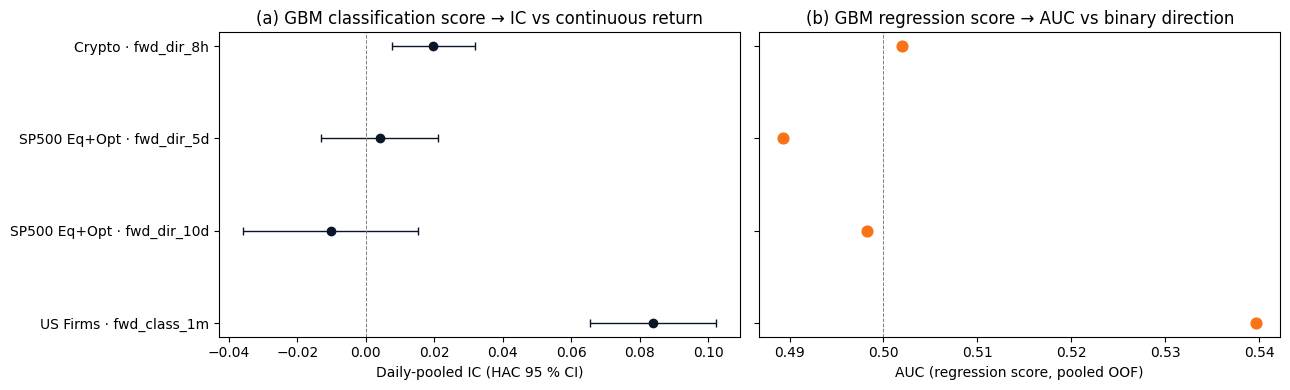

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))
labels_y = [f"{r['short_name']} · {r['dir_label']}" for r in sym_df.iter_rows(named=True)]
y = np.arange(sym_df.height)

ax = axes[0]
ic = sym_df["cls_score_ic"].to_numpy()
lo = sym_df["cls_score_ic_lo"].to_numpy()
hi = sym_df["cls_score_ic_hi"].to_numpy()
ax.errorbar(
    ic,
    y,
    xerr=[ic - lo, hi - ic],
    fmt="o",
    color=COLORS.get("blue", "#3B82F6"),
    capsize=3,
    lw=1,
)
ax.axvline(0, color="gray", lw=0.7, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(labels_y)
ax.invert_yaxis()
ax.set_xlabel("Daily-pooled IC (HAC 95 % CI)")
ax.set_title("(a) GBM classification score → IC vs continuous return")

ax = axes[1]
auc = sym_df["reg_score_auc"].to_numpy()
ax.scatter(auc, y, color=COLORS.get("orange", "#F97316"), s=60, zorder=3)
ax.axvline(0.5, color="gray", lw=0.7, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels([])
ax.invert_yaxis()
ax.set_xlabel("AUC (regression score, pooled OOF)")
ax.set_title("(b) GBM regression score → AUC vs binary direction")

fig.tight_layout()
fig.show()

Read the two panels alongside Ch11 §6b. For GBM, Direction A — the
classification score's IC against the continuous return — is positive on
every (CS, label) and the CI excludes zero on the same panels where the
linear classifier did, with comparable magnitudes. Direction B — the
regression score's AUC against the binary direction — likewise sits
within $\pm 0.03$ of 0.5 across the panels tested. The same asymmetry
carries over from the linear family: cross-sectional rank correlation
(Direction A) responds to magnitude information that pooled binary AUC
(Direction B) discards, and the loss-function choice (logistic vs MSE/
MAE/Huber) shifts which discriminative content the score carries.
Downstream, both score types continue to feed long–short construction
in the strategy chapters.

## 7. Interpretability

Three diagnostics use saved booster + Ridge coefficient artifacts: feature-
importance rank shift versus Ridge (7a), per-fold rank stability of GBM
importances (7b), and the TabM-vs-GBM-vs-Linear three-way picture (7c).

In [30]:
NON_FEATURE_COLS = {"timestamp", "symbol", "stock_id", "product", "position", "instrument_id"}
IMPORTANCE_CASES = ["etfs", "sp500_options", "us_firm_characteristics", "us_equities_panel"]


def _load_ridge_importance(cs: str, label: str) -> dict[str, float]:
    """Mean |coefficient| across folds for the highest-IC Ridge config."""
    db = sqlite3.connect(get_case_study_dir(cs) / "run_log" / "registry.db")
    rows = db.execute(
        "SELECT training_hash, config_name FROM training_runs WHERE family='linear' AND label=?",
        (label,),
    ).fetchall()
    db.close()
    frames = []
    for h, cfg in rows:
        coef_path = get_case_study_dir(cs) / "run_log" / "training" / h / "coefficients.parquet"
        if coef_path.exists():
            frames.append(pl.read_parquet(coef_path).with_columns(pl.lit(cfg).alias("config_name")))
    if not frames:
        return {}
    coefs = pl.concat(frames)
    ridge_only = coefs.filter(
        pl.col("config_name").str.starts_with("ridge") & (pl.col("feature") != "_intercept_")
    )
    if ridge_only.is_empty():
        return {}
    return dict(
        ridge_only.group_by("feature")
        .agg(pl.col("coefficient").abs().mean().alias("abs_coef"))
        .sort("abs_coef", descending=True)
        .iter_rows()
    )

### 7a. Feature importance — GBM versus Ridge rank shift

For each case study with both saved boosters and Ridge coefficient
parquets, features are ranked by GBM gain importance (mean across folds)
and by Ridge mean |coefficient|. The rank shift `lin_rank − gbm_rank` is
positive for features GBM promotes over Ridge (typically interaction or
regime features) and negative for features Ridge promotes over GBM
(typically monotonic predictors).

In [31]:
rank_shift_summary = []
for cs in IMPORTANCE_CASES:
    label = PRIMARY_LABELS[cs]
    gbm_imp_df = load_gbm_feature_importance(cs, label=label, top_n=50)
    if gbm_imp_df is None or gbm_imp_df.is_empty():
        continue
    gbm_imp = dict(
        gbm_imp_df.group_by("feature")
        .agg(pl.col("importance").mean().alias("imp"))
        .sort("imp", descending=True)
        .iter_rows()
    )
    ridge_imp = _load_ridge_importance(cs, label)
    common = set(gbm_imp) & set(ridge_imp)
    if not common:
        continue
    gbm_ranks = {f: r for r, f in enumerate(sorted(gbm_imp, key=lambda x: -gbm_imp[x]), 1)}
    ridge_ranks = {f: r for r, f in enumerate(sorted(ridge_imp, key=lambda x: -ridge_imp[x]), 1)}
    shifts = pl.DataFrame(
        [
            {
                "feature": f,
                "gbm_rank": gbm_ranks[f],
                "ridge_rank": ridge_ranks[f],
                "rank_shift": ridge_ranks[f] - gbm_ranks[f],
            }
            for f in common
        ]
    )
    rank_shift_summary.append(
        {
            "short_name": SHORT_NAMES[cs],
            "n_common_features": shifts.height,
            "median_abs_shift": float(shifts["rank_shift"].abs().median()),
            "max_gbm_promotion": int(shifts["rank_shift"].max() or 0),
            "max_ridge_promotion": int(
                -shifts["rank_shift"].min() if shifts["rank_shift"].min() else 0
            ),
            "_shifts": shifts,
        }
    )

print(f"Computed GBM-vs-Ridge rank shifts for {len(rank_shift_summary)} case studies.")
shift_summary_df = (
    pl.DataFrame(
        [{k: v for k, v in r.items() if not k.startswith("_")} for r in rank_shift_summary]
    )
    if rank_shift_summary
    else pl.DataFrame()
)
shift_summary_df

Computed GBM-vs-Ridge rank shifts for 4 case studies.


short_name,n_common_features,median_abs_shift,max_gbm_promotion,max_ridge_promotion
str,i64,f64,i64,i64
"""ETFs""",50,19.5,61,36
"""SP500 Options""",50,9.0,35,37
"""US Firms""",50,11.5,30,33
"""US Equities""",50,21.0,64,43


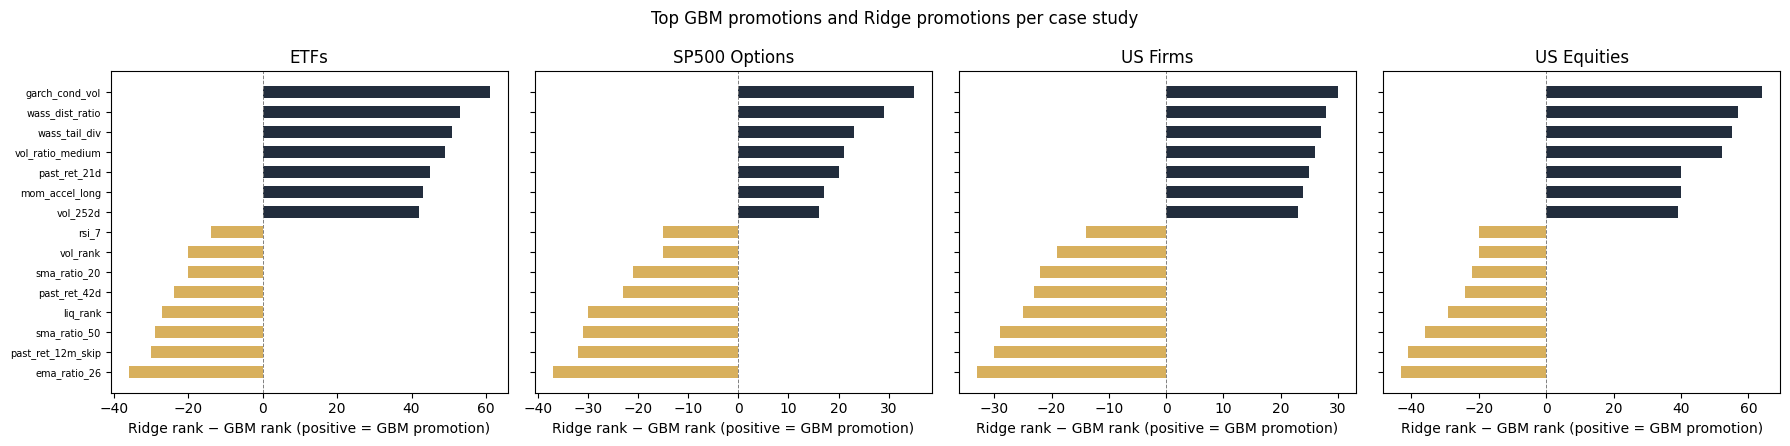

In [32]:
if rank_shift_summary:
    fig, axes = plt.subplots(
        1,
        len(rank_shift_summary),
        figsize=(4.5 * len(rank_shift_summary), 4.5),
        sharey=True,
    )
    if len(rank_shift_summary) == 1:
        axes = [axes]
    for ax, entry in zip(axes, rank_shift_summary, strict=False):
        s = entry["_shifts"].sort("rank_shift", descending=True)
        n_show = min(15, s.height)
        top_promotions = s.head(n_show // 2)
        bot_promotions = s.tail(n_show - top_promotions.height)
        plot_set = pl.concat([top_promotions, bot_promotions]).sort("rank_shift", descending=False)
        y = np.arange(plot_set.height)
        colors = [
            COLORS.get("blue", "#3B82F6") if v > 0 else COLORS.get("amber", "#F59E0B")
            for v in plot_set["rank_shift"].to_list()
        ]
        ax.barh(y, plot_set["rank_shift"].to_numpy(), color=colors, height=0.6, alpha=0.9)
        ax.set_yticks(y)
        ax.set_yticklabels(plot_set["feature"].to_list(), fontsize=7)
        ax.axvline(0, color="gray", linewidth=0.7, linestyle="--")
        ax.set_xlabel("Ridge rank − GBM rank (positive = GBM promotion)")
        ax.set_title(entry["short_name"])
    fig.suptitle("Top GBM promotions and Ridge promotions per case study")
    fig.tight_layout()
    fig.show()

Where both families have saved per-fold artifacts, the rank-shift
distribution carries a recognizable pattern: GBM promotes regime,
volatility-rank, and cross-asset interaction features that Ridge ranks
low; Ridge promotes monotonic pricing and momentum features that GBM
splits coarsely. The asymmetric carriage of the same feature library is
the mechanism behind the GBM-minus-linear delta on the panels where it
is positive: GBMs exploit conditional structure that Ridge's
coefficients cannot encode in a single direction.

### 7b. Per-fold feature-rank stability

For each case study, the top-10 GBM features by mean gain are identified,
then re-ranked within each fold. Mean pairwise Spearman rank correlation
across folds quantifies whether the same features dominate every fold or
whether the top-N rotates regime to regime.

In [33]:
stability_rows = []
for cs in IMPORTANCE_CASES:
    label = PRIMARY_LABELS[cs]
    gbm_imp_df = load_gbm_feature_importance(cs, label=label, top_n=30)
    if gbm_imp_df is None or gbm_imp_df.is_empty():
        continue
    top_features = (
        gbm_imp_df.group_by("feature")
        .agg(pl.col("importance").mean().alias("mean_imp"))
        .sort("mean_imp", descending=True)
        .head(10)["feature"]
        .to_list()
    )
    sub = (
        gbm_imp_df.filter(pl.col("feature").is_in(top_features))
        .group_by(["feature", "fold_id"])
        .agg(pl.col("importance").mean())
    )
    pivot = sub.pivot(index="feature", on="fold_id", values="importance").drop_nulls()
    fold_cols = [c for c in pivot.columns if c != "feature"]
    if len(fold_cols) < 2 or pivot.height < 3:
        continue
    fold_arrays = [pivot[c].to_numpy() for c in fold_cols]
    ranks = [np.argsort(np.argsort(-arr)) for arr in fold_arrays]
    pairs = []
    for i in range(len(ranks)):
        for j in range(i + 1, len(ranks)):
            ai, aj = ranks[i], ranks[j]
            if ai.size > 1 and aj.size > 1:
                pairs.append(np.corrcoef(ai, aj)[0, 1])
    if not pairs:
        continue
    stability_rows.append(
        {
            "short_name": SHORT_NAMES[cs],
            "n_folds": len(fold_cols),
            "n_top_features": len(top_features),
            "mean_pairwise_rank_corr": float(np.mean(pairs)),
            "min_pairwise_rank_corr": float(np.min(pairs)),
        }
    )

stability_df = pl.DataFrame(stability_rows)
print("Per-fold feature-rank stability for the top-10 GBM features per case study:")
stability_df

Per-fold feature-rank stability for the top-10 GBM features per case study:


short_name,n_folds,n_top_features,mean_pairwise_rank_corr,min_pairwise_rank_corr
str,i64,i64,f64,f64
"""ETFs""",8,10,0.544589,-0.187879
"""SP500 Options""",2,10,-0.212121,-0.212121
"""US Firms""",10,10,0.77266,0.575758
"""US Equities""",16,10,0.020101,-0.951515


US Firms shows the highest mean pairwise rank correlation across folds
(0.77, min 0.58) — the same features carry the gain across regimes,
and the per-fold IC distribution (§4a) reflects the same feature pool
used in different proportions. ETFs sits at moderate stability
(mean 0.51, min −0.22) — the top-N rotates but a core set persists.
US Equities and SP500 Options show near-zero or negative mean rank
correlation (0.04 and −0.21 respectively), with single folds whose
feature ordering inverts the others — symptomatic of regime-distinct
sample windows in those panels rather than instability of the
underlying GBM fit. The stability diagnostic and the headline IC are
not collinear: a panel whose GBM signal is credibly nonzero can still
have a top-N feature set that rotates fold to fold.

### 7c. TabM versus GBM versus Linear — three-way picture

TabM (Gorishniy et al., ICLR 2025) is a rank-one adapter MLP ensemble that
operates on the same flat feature matrix as GBMs. For each case study
the highest daily-pooled IC across configurations within each of the
three families is shown side by side at the primary label.

In [34]:
tabm_rank1 = collect_rank1_per_cs(CASE_STUDY_IDS, family="tabular_dl")

three_way = (
    gbm_rank1.select("case_study", "short_name", pl.col("ic_mean_daily").alias("gbm_ic"))
    .join(
        linear_rank1.select("case_study", pl.col("ic_mean_daily").alias("lin_ic")),
        on="case_study",
        how="left",
    )
    .join(
        tabm_rank1.select("case_study", pl.col("ic_mean_daily").alias("tabm_ic")),
        on="case_study",
        how="left",
    )
    .sort("gbm_ic", descending=True)
)
print("Linear / GBM / TabM highest-validation-IC daily-pooled IC per case study (primary label):")
three_way.select(
    "short_name",
    pl.col("lin_ic").round(4).alias("linear"),
    pl.col("gbm_ic").round(4).alias("gbm"),
    pl.col("tabm_ic").round(4).alias("tabm"),
)

Linear / GBM / TabM highest-validation-IC daily-pooled IC per case study (primary label):


short_name,linear,gbm,tabm
str,f64,f64,f64
"""US Firms""",-0.0036,0.0803,0.0308
"""ETFs""",0.0535,0.0371,0.0408
"""CME Futures""",-0.0001,0.0322,0.0043
"""US Equities""",0.0155,0.0318,0.0167
"""SP500 Options""",0.0071,0.0182,0.0017
"""Crypto""",0.0086,0.011,0.003
"""NQ100""",0.0049,0.006,null
"""SP500 Eq+Opt""",-0.0059,0.0057,0.0114
"""FX""",0.0052,0.0025,0.0067


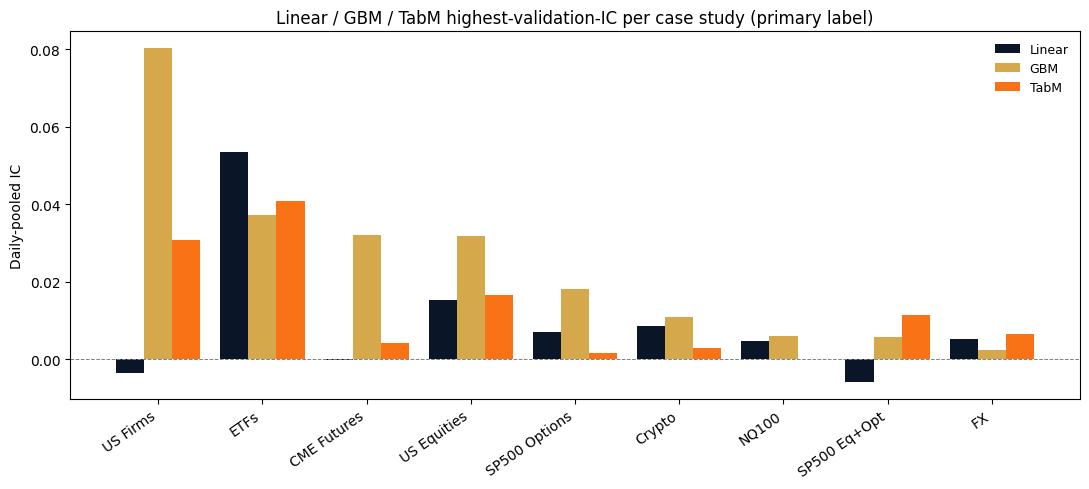

In [35]:
fig, ax = plt.subplots(figsize=(11, 5))
cs_sorted = three_way["short_name"].to_list()
x = np.arange(len(cs_sorted))
width = 0.27
fam_colors = {
    "linear": COLORS.get("blue", "#3B82F6"),
    "gbm": COLORS.get("amber", "#F59E0B"),
    "tabm": COLORS.get("orange", "#F97316"),
}
ax.bar(
    x - width,
    three_way["lin_ic"].to_numpy(),
    width=width,
    color=fam_colors["linear"],
    label="Linear",
)
ax.bar(x, three_way["gbm_ic"].to_numpy(), width=width, color=fam_colors["gbm"], label="GBM")
ax.bar(
    x + width, three_way["tabm_ic"].to_numpy(), width=width, color=fam_colors["tabm"], label="TabM"
)
ax.axhline(0, color="gray", linewidth=0.7, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(cs_sorted, rotation=35, ha="right")
ax.set_ylabel("Daily-pooled IC")
ax.set_title("Linear / GBM / TabM highest-validation-IC per case study (primary label)")
ax.legend(frameon=False, fontsize=9, loc="best")
fig.tight_layout()
fig.show()

TabM is trained on the same feature matrix as GBM and is missing on
NASDAQ-100 (no `tabular_dl` rows in the registry) — the gap is shown
explicitly. The three-family picture is heterogeneous: TabM exceeds
GBM on a few panels (ETFs, SP500 Eq+Opt, FX) and falls behind on
others (US Firms by ≈0.05 IC, SP500 Options by ≈0.017 IC). On most
panels the TabM-vs-linear delta has the same sign as the GBM-vs-
linear delta, consistent with both extracting some shared
nonlinear cross-sectional structure from the input pool, but the
magnitudes are not interchangeable. Ensemble-style combinations of
the three families are a natural extension explored in Ch20.

## 8. Cross-CS Takeaways

- **GBM clears the IC CI = 0 line on five case studies at the primary
  label** (US Firms, US Equities, SP500 Options, CME Futures,
  NASDAQ-100), with ETFs just below at $|t_{HAC}| \approx 1.9$. Crypto,
  FX, and SP500 Eq+Opt remain CI-overlap-zero regimes for cross-
  sectional rank prediction even with tree splits available.
- **Loss-family resolution is small on most panels**: MAE achieves the
  highest IC on eight of the nine regression-primary case studies and
  MSE on the remaining one (ETFs); Huber is competitive but never the
  highest. The IC gaps between the three losses inside a case study
  are typically inside one CI half-width — US Firms is the exception
  (MAE outscores Huber/MSE by roughly 2–3 half-widths).
- **Tree depth is a low-resolution knob**: the depth heatmap
  concentrates higher values in the 15–63 leaf interior, but inside
  any case study the IC differences between leaf profiles are usually
  inside one CI half-width.
- **Checkpoint dynamics show interior peaks** (typically 100–400 trees)
  on most panels; the late-trajectory HAC CI bands are the tightest,
  making the early-stopping schedule meaningful.
- **GBM minus linear, paired by fold, has a CI that excludes zero on
  four of the nine case studies** (US Firms, CME Futures, US Equities,
  SP500 Eq+Opt). On the remaining panels the per-fold delta straddles
  zero; the two families are statistically indistinguishable on the
  same fold set.
- **GBM holdout coverage on the primary label is sparse** — only CME
  Futures and US Equities have a `split='holdout'` GBM row in the
  locked registry. Both sit within the validation HAC CI; with $n=2$,
  no aggregate generalization claim is supported.
- **Direction A and Direction B are not symmetric for GBM either**:
  GBM classification scores carry meaningful continuous-return ranking
  on Crypto ($t_{HAC}=3.2$) and US Firms ($t_{HAC}=8.5$); GBM
  regression scores' pooled AUC against the binary direction sits
  within $\pm 0.04$ of 0.5 across the four (CS, label) pairs tested
  (US Firms reaches 0.540; the other three sit within $\pm 0.02$).
  The same loss-function-shaped asymmetry that Ch11 §6b documented for
  linear also holds for GBM.
- **Feature-importance rank shift between GBM and Ridge is large**
  (median absolute shifts of 9–21 ranks among shared top-50 features)
  and asymmetric: GBM promotes regime and interaction features that
  Ridge ranks low; Ridge promotes monotonic pricing features that GBM
  splits coarsely. Per-fold top-10 rank stability is high on US Firms
  (mean pairwise rank correlation 0.77), moderate on ETFs (0.51), and
  near zero or negative on US Equities (0.04) and SP500 Options (−0.21)
  — the stability diagnostic and the headline IC are not collinear.
- **TabM and GBM extract some shared nonlinear structure**: the TabM-
  vs-linear and GBM-vs-linear deltas have the same sign on most
  panels, but their magnitudes are not interchangeable — TabM exceeds
  GBM on ETFs, SP500 Eq+Opt, and FX, and falls below GBM on US Firms
  and SP500 Options. NASDAQ-100 has no TabM coverage in the registry.

**Next**: Ch13 extends the comparison with temporal deep learning
architectures; Ch14 adds latent-factor models on the qualifying panels.